In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.datasets import load_gbsg2
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
 
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from lifelines import CoxPHFitter
 
from sklearn.preprocessing import MinMaxScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [7]:
# need to choose patient_id from OUS_D1 and OUS_OS_target in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [8]:
# Merge MAASTRO_D1 with response_ous
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [9]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [10]:
# Check if some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [11]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [12]:
# Change the form of MAASTRO 
# X
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]

# y_MAASTRO into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

# Check the shape of clincial_test
clinical_test.shape

(99, 16)

# Feature Selection

In [13]:
# Define the columns to be excluded from standardization
excluded_columns = ['female', 
                    'cavum_oris',
                    'oropharynx',
                    'hypopharynx',
                    'larynx',
                    'histgrade_high',
                    'hpv_related',
                    'charlson',
                    'uicc8_III-IV'
                   ]

y_event_os = y['event_OS']

final_sum_results = []  # Store sum results across all iterations

for random_state in range(10): 
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    sum_results = []  # Store sum results for each fold
    
    for train_index, test_index in skf.split(X, y_event_os):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Standardize the included columns
        scaler = MinMaxScaler()
        X_train_std = scaler.fit_transform(X_train)
        X_test_std = scaler.transform(X_test)

        # Change it to a dataframe
        X_train_std = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
        X_test_std = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)
        
        final_train_df = pd.concat([X_train_std, y_train], axis=1)
        final_test_df = pd.concat([X_test_std, y_test], axis=1)

        # Fit Cox proportional hazards regression model
        coxph = CoxPHFitter(penalizer=0.0001)
        coxph.fit(final_train_df, duration_col='OS', event_col='event_OS')

        # Get coefficients and associated feature names
        coefficients = coxph.summary['coef']
        feature_names = coxph.summary.index

        # Create a DataFrame to store coefficients and feature names
        coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

        # Take absolute values of coefficients
        coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

        # Sort coefficients by absolute value to identify important features
        sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)
        
        # Sum absolute coefficients for each feature
        sum_abs_coefficient = sorted_coefficients_df.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
        
        # Append to sum_results for this fold
        sum_results.append(sum_abs_coefficient)

    # Concatenate sum_results for all folds
    fold_sum_results = pd.concat(sum_results)
    
    # Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all folds
    final_sum_fold = fold_sum_results.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
    
    # Append to final_sum_results for all random states
    final_sum_results.append(final_sum_fold)

# Concatenate the DataFrames for all random states
final_result = pd.concat(final_sum_results)

# Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all iterations and folds
final_sum = final_result.groupby('Feature')['Abs_Coefficient'].sum().reset_index()

# Rename the column for clarity
final_sum.columns = ['Feature', 'Final_Sum_Abs_Coefficient']

final_sum_sorted = final_sum.sort_values(by='Final_Sum_Abs_Coefficient', ascending=False)

# Display the final result
print(final_sum_sorted)

<lifelines.CoxPHFitter: fitted with 111 total observations, 65 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 65 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 66 right-censored observations>

...

<lifelines.CoxPHFitter: fitted with 111 total observations, 65 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 66 right-censored observations>

           Feature  Final_Sum_Abs_Coefficient
2              TLG                 235.376109
0              MTV                 208.843987
8      hpv_related                  77.430708
12      pack_years                  55.240130
3              age                  49.613715
1          SUVpeak                  42.206120
13    uicc8_III-IV                  36.968251
9      hypopharynx                  30.384528
5         charlson                  25.895731
11      oropharynx                  19.861037
10          larynx                  17.511419
4       cavum_oris                  14.978429
6           female                  14.058316
7   histgrade_high                   9.139413


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using CoxPH Fitter')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

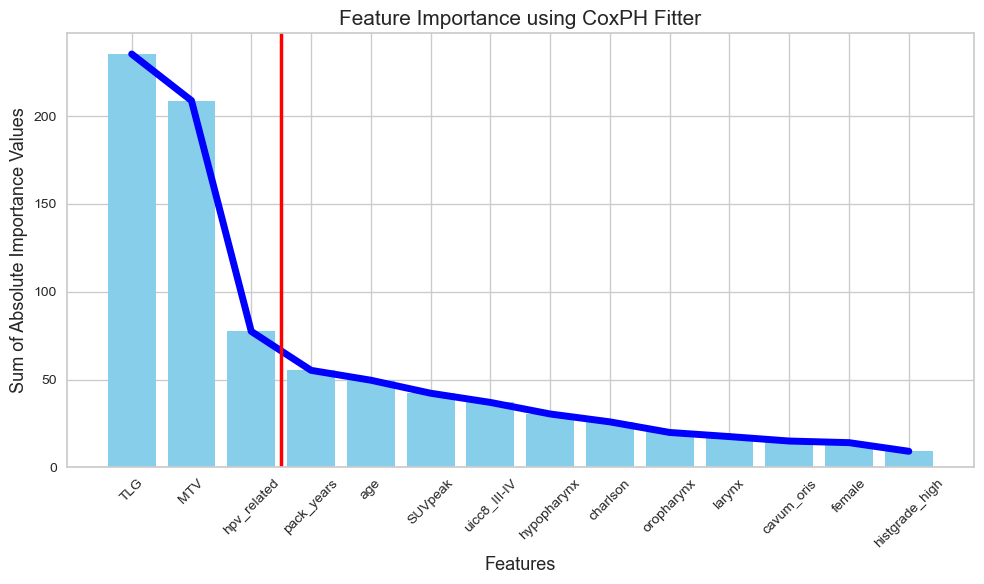

In [14]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(final_sum_sorted['Feature'], 
        final_sum_sorted['Final_Sum_Abs_Coefficient'], 
        color='skyblue')
plt.plot(final_sum_sorted['Feature'], 
         final_sum_sorted['Final_Sum_Abs_Coefficient'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using CoxPH Fitter', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=2.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [15]:
selected_features = final_sum_sorted[0:3]['Feature']
selected_features

2            TLG
0            MTV
8    hpv_related
Name: Feature, dtype: object

In [16]:
# Selecting features in the DataFrame
X_cfi = X[selected_features]
X_new = X_cfi.copy()

X_MAASTRO_cfi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_cfi.copy()

# Standardization

In [17]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = MinMaxScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [18]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [19]:
X_new

,TLG,MTV,hpv_related
0,86.228420,7.934,0.0
1,7.040100,1.656,0.0
2,83.569669,14.502,0.0
3,5.567091,2.440,0.0
4,16.150550,3.668,0.0
...,...,...,...
134,26.280140,3.650,1.0
135,101.754834,18.967,1.0
136,66.273201,6.370,1.0
137,71.832443,12.443,1.0


In [20]:
X_new_std

,TLG,MTV,hpv_related
0,0.044798,0.074159,0.0
1,0.001900,0.008512,0.0
2,0.043358,0.142839,0.0
3,0.001102,0.016710,0.0
4,0.006835,0.029551,0.0
...,...,...,...
134,0.012323,0.029363,1.0
135,0.053209,0.189529,1.0
136,0.033988,0.057805,1.0
137,0.037000,0.121309,1.0


In [21]:
MAASTRO_new

,TLG,MTV,hpv_related
0,263.611623,22.841,1
1,36.980700,5.660,0
2,74.636342,7.791,0
3,46.791979,7.908,0
4,107.637514,15.237,1
...,...,...,...
94,144.490782,6.110,0
95,69.214868,7.182,0
96,102.594274,16.483,1
97,103.229492,9.981,1


In [22]:
MAASTRO_new_std

,TLG,MTV,hpv_related
0,0.140892,0.230038,1
1,0.018119,0.050381,0
2,0.038519,0.072664,0
3,0.023434,0.073887,0
4,0.056396,0.150525,1
...,...,...,...
94,0.076361,0.055086,0
95,0.035582,0.066296,0
96,0.053664,0.163554,1
97,0.054008,0.095564,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [23]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 17:24:24,433] A new study created in memory with name: no-name-243e70d5-f4fc-420e-a948-766efb87632f


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6623376623376623
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.803921568627451


[I 2024-04-19 17:24:25,682] A new study created in memory with name: no-name-665354bd-7c75-470f-bef2-bc5eddd038a7


Fold 4 C-index: 0.8270042194092827
Fold 5 C-index: 0.6197183098591549
[I 2024-04-19 17:24:25,653] Trial 0 finished with value: 0.7361677806181388 and parameters: {}. Best is trial 0 with value: 0.7361677806181388.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7361677806181388], datetime_start=datetime.datetime(2024, 4, 19, 17, 24, 24, 632512), datetime_complete=datetime.datetime(2024, 4, 19, 17, 24, 25, 653348), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7361677806181388


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.17915906502790455
Fold 2 IBS: 0.20170223404947618
Fold 3 IBS: 0.17505468449703354
Fold 4 IBS: 0.14253965894637302
Fold 5 IBS: 0.2695925587123099
[I 2024-04-19 17:24:26,979] Trial 0 finished with value: 0.19360964024661945 and parameters: {}. Best is trial 0 with value: 0.19360964024661945.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.19360964024661945], datetime_start=datetime.datetime(2024, 4, 19, 17, 24, 25, 717346), datetime_complete=datetime.datetime(2024, 4, 19, 17, 24, 26, 978890), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.19360964024661945


In [24]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [25]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.736
train_ibs:  0.194


#### Test

In [26]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [27]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.623
IBS score: 0.234


In [28]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [29]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [30]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:24:27,569] A new study created in memory with name: no-name-6a579493-1e74-495a-8bb5-760276bd8cfb


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7575757575757576
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.7328431372549019


[I 2024-04-19 17:24:28,041] A new study created in memory with name: no-name-e3aa4a74-92fe-49cf-8bdb-073e8262b586


Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.5868544600938967
[I 2024-04-19 17:24:28,036] Trial 0 finished with value: 0.6975692731548933 and parameters: {}. Best is trial 0 with value: 0.6975692731548933.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6975692731548933], datetime_start=datetime.datetime(2024, 4, 19, 17, 24, 27, 617793), datetime_complete=datetime.datetime(2024, 4, 19, 17, 24, 28, 36104), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6975692731548933


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651764739065
Fold 2 IBS: 0.221577916505828
Fold 3 IBS: 0.20453594517659848
Fold 4 IBS: 0.2247380366950916
Fold 5 IBS: 0.21812431575089974
[I 2024-04-19 17:24:29,339] Trial 0 finished with value: 0.2165905463551617 and parameters: {}. Best is trial 0 with value: 0.2165905463551617.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905463551617], datetime_start=datetime.datetime(2024, 4, 19, 17, 24, 28, 276218), datetime_complete=datetime.datetime(2024, 4, 19, 17, 24, 29, 338999), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905463551617


In [31]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.698
train_ibs:  0.217


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.589


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [35]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [36]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:24:29,704] A new study created in memory with name: no-name-32256d42-74c1-4477-ac51-8f16d63591cd


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6623376623376623
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8270042194092827


[I 2024-04-19 17:24:31,342] A new study created in memory with name: no-name-1e31b5a4-757e-4869-b289-25947c672b22


Fold 5 C-index: 0.6244131455399061
[I 2024-04-19 17:24:31,336] Trial 0 finished with value: 0.7361263555974262 and parameters: {}. Best is trial 0 with value: 0.7361263555974262.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7361263555974262], datetime_start=datetime.datetime(2024, 4, 19, 17, 24, 29, 775128), datetime_complete=datetime.datetime(2024, 4, 19, 17, 24, 31, 336531), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7361263555974262


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.1790043849092267
Fold 2 IBS: 0.20299776142539347
Fold 3 IBS: 0.1747802769117768
Fold 4 IBS: 0.1424894294972704
Fold 5 IBS: 0.2691519164283265
[I 2024-04-19 17:24:32,984] Trial 0 finished with value: 0.19368475383439876 and parameters: {}. Best is trial 0 with value: 0.19368475383439876.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.19368475383439876], datetime_start=datetime.datetime(2024, 4, 19, 17, 24, 31, 383271), datetime_complete=datetime.datetime(2024, 4, 19, 17, 24, 32, 984030), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.19368475383439876


In [37]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [38]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.736
train_ibs:  0.194


#### Test

In [39]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [40]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.624


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.232


In [41]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [42]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 17:24:33,836] A new study created in memory with name: no-name-00f44ef9-ad1c-41e0-a505-d4206fce27b1


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6623376623376623
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.6244131455399061
[I 2024-04-19 17:24:35,691] Trial 0 finished with value: 0.7369702374539663 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7369702374539663.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8270042194092827
Fold 5 C-index: 0.6244131455399061
[I 2024-04-19 17:24:37,790] Trial 1 finished with value: 0.7369921564632271 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.7369921564632271.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.6244131455399061
[I 2024-04-19 17:24:39,924] Trial 2 finished with value: 0.7378360383197672 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 5 C-index: 0.5868544600938967
[I 2024-04-19 17:25:13,648] Trial 23 finished with value: 0.6975692731548933 and parameters: {'l1_ratio': 0.002373744016739676}. Best is trial 18 with value: 0.7545692386340426.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.6244131455399061
[I 2024-04-19 17:25:15,633] Trial 24 finished with value: 0.7378360383197672 and parameters: {'l1_ratio': 0.20495632796046423}. Best is trial 18 with value: 0.7545692386340426.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8270042194092827
Fold 5 C-index: 0.6244131455399061
[I 2024-04-19 17:25:17,523] Trial 25 finished with value: 0.7369921564632271 and parameters: {'l1_ratio': 0.3804525958179419}. Best is trial 18 with value: 0.7545692386340426.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index

Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.7328431372549019
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.6431924882629108
[I 2024-04-19 17:25:53,983] Trial 47 finished with value: 0.7088368787886961 and parameters: {'l1_ratio': 0.04162250199642466}. Best is trial 32 with value: 0.7564885979270556.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.6244131455399061
[I 2024-04-19 17:25:55,948] Trial 48 finished with value: 0.7378360383197672 and parameters: {'l1_ratio': 0.2216981652255272}. Best is trial 32 with value: 0.7564885979270556.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.6244131455399061
[I 2024-04-19 17:25:57,817] Trial 49 finished with value: 0.7378360383197672 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 32 with value: 0.

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.1790189965530924
Fold 2 IBS: 0.20322457658257675
Fold 3 IBS: 0.17480034284090357
Fold 4 IBS: 0.14245321567247068
Fold 5 IBS: 0.2692529267244887
[I 2024-04-19 17:27:21,093] Trial 0 finished with value: 0.19375001167470646 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.19375001167470646.
Fold 1 IBS: 0.1790298600876611
Fold 2 IBS: 0.20334268972734262
Fold 3 IBS: 0.17481922741752595
Fold 4 IBS: 0.14243960178591644
Fold 5 IBS: 0.2692964495377793
[I 2024-04-19 17:27:23,382] Trial 1 finished with value: 0.19378556571124508 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.19375001167470646.
Fold 1 IBS: 0.17903191077170935
Fold 2 IBS: 0.20335442822332572
Fold 3 IBS: 0.1748191493358598
Fold 4 IBS: 0.14243779354798755
Fold 5 IBS: 0.2692978724880154
[I 2024-04-19 17:27:25,521] Trial 2 finished with value: 0.19378823087337954 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.193750011674706

Fold 1 IBS: 0.17901110814529686
Fold 2 IBS: 0.20306030480252005
Fold 3 IBS: 0.1747843797217394
Fold 4 IBS: 0.14247302708612497
Fold 5 IBS: 0.26917541036704384
[I 2024-04-19 17:28:05,019] Trial 25 finished with value: 0.19370084602454501 and parameters: {'l1_ratio': 0.9106143729430608}. Best is trial 11 with value: 0.19368659539421426.
Fold 1 IBS: 0.17902447413472333
Fold 2 IBS: 0.2032545722404588
Fold 3 IBS: 0.17480023383150706
Fold 4 IBS: 0.14244816904822202
Fold 5 IBS: 0.2692570311105599
[I 2024-04-19 17:28:06,995] Trial 26 finished with value: 0.1937568960730942 and parameters: {'l1_ratio': 0.6273790955054189}. Best is trial 11 with value: 0.19368659539421426.
Fold 1 IBS: 0.17902321786812575
Fold 2 IBS: 0.20311362297229546
Fold 3 IBS: 0.17479210562067124
Fold 4 IBS: 0.1424555007558006
Fold 5 IBS: 0.26923706971714273
[I 2024-04-19 17:28:08,813] Trial 27 finished with value: 0.19372430338680716 and parameters: {'l1_ratio': 0.7517964642342185}. Best is trial 11 with value: 0.1936865953

Fold 1 IBS: 0.17903385639358238
Fold 2 IBS: 0.20441417799701794
Fold 3 IBS: 0.17478223657291445
Fold 4 IBS: 0.22070687724624155
Fold 5 IBS: 0.2692228464734135
[I 2024-04-19 17:28:45,408] Trial 50 finished with value: 0.20963199893663392 and parameters: {'l1_ratio': 0.08888770157152942}. Best is trial 47 with value: 0.19368531221444493.
Fold 1 IBS: 0.1790066657194841
Fold 2 IBS: 0.2031382573850545
Fold 3 IBS: 0.17478865591219722
Fold 4 IBS: 0.14248052890928287
Fold 5 IBS: 0.2691759072679206
[I 2024-04-19 17:28:46,874] Trial 51 finished with value: 0.19371800303878786 and parameters: {'l1_ratio': 0.9495136153828908}. Best is trial 47 with value: 0.19368531221444493.
Fold 1 IBS: 0.179001803228857
Fold 2 IBS: 0.20306079642574568
Fold 3 IBS: 0.17477202485529894
Fold 4 IBS: 0.14248561496193332
Fold 5 IBS: 0.26914049056870476
[I 2024-04-19 17:28:48,335] Trial 52 finished with value: 0.19369214600810794 and parameters: {'l1_ratio': 0.9890190374631385}. Best is trial 47 with value: 0.1936853122

Fold 1 IBS: 0.17901108674815833
Fold 2 IBS: 0.2030370721083716
Fold 3 IBS: 0.17477956244776985
Fold 4 IBS: 0.14248242089138147
Fold 5 IBS: 0.26915741015684935
[I 2024-04-19 17:29:24,814] Trial 75 finished with value: 0.19369351047050615 and parameters: {'l1_ratio': 0.9681424935221649}. Best is trial 47 with value: 0.19368531221444493.
Fold 1 IBS: 0.17901882309232692
Fold 2 IBS: 0.20325356777521783
Fold 3 IBS: 0.174790588261068
Fold 4 IBS: 0.14245827042100065
Fold 5 IBS: 0.269232164527724
[I 2024-04-19 17:29:26,343] Trial 76 finished with value: 0.19375068281546748 and parameters: {'l1_ratio': 0.7841240871388664}. Best is trial 47 with value: 0.19368531221444493.
Fold 1 IBS: 0.17900404934789851
Fold 2 IBS: 0.20300598617033344
Fold 3 IBS: 0.1747791897989002
Fold 4 IBS: 0.14248892673040783
Fold 5 IBS: 0.2691504130706585
[I 2024-04-19 17:29:27,986] Trial 77 finished with value: 0.1936857130236397 and parameters: {'l1_ratio': 0.9985526678179714}. Best is trial 47 with value: 0.1936853122144

In [43]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [44]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.756
train_ibs:  0.194


#### Test

In [45]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [46]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.05413792748818495)

test_cindex : 0.589


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.9992471693779538)

test_ibs:  0.232


In [47]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [48]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 17:30:03,349] A new study created in memory with name: no-name-9634bbb1-8f12-4da8-bc9b-083eda6f1ef6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.8186274509803921
Fold 4 C-index: 0.8713080168776371
Fold 5 C-index: 0.6737089201877934
[I 2024-04-19 17:30:15,724] Trial 0 finished with value: 0.7658565832368702 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7658565832368702.
Fold 1 C-index: 0.6688311688311688
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.7679324894514767
Fold 5 C-index: 0.6666666666666666
[I 2024-04-19 17:30:25,979] Trial 1 finished with value: 0.7001678577069492 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 

Fold 5 C-index: 0.7253521126760564
[I 2024-04-19 17:32:31,962] Trial 15 finished with value: 0.7292250941852292 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 2, 'min_samples_leaf': 10, 'max_depth': 14, 'n_estimators': 362, 'oob_score': True, 'max_samples': 0.4747428535255964, 'max_features': None, 'min_weight_fraction_leaf': 0.10572555214268262, 'warm_start': True}. Best is trial 14 with value: 0.8090715463724834.
Fold 1 C-index: 0.7251082251082251
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7769607843137255
Fold 4 C-index: 0.8713080168776371
Fold 5 C-index: 0.7206572769953051
[I 2024-04-19 17:32:35,187] Trial 16 finished with value: 0.7661282892304071 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 7, 'min_samples_leaf': 3, 'max_depth': 14, 'n_estimators': 175, 'oob_score': True, 'max_samples': 0.8580090893351726, 'max_features': None, 'min_weight_fraction_leaf': 0.22594306843997863, 'warm_start': True}. Best is trial 14 with value: 0.8090715463724834

Fold 1 C-index: 0.6731601731601732
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.7524509803921569
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.7981220657276995
[I 2024-04-19 17:33:13,729] Trial 30 finished with value: 0.7755822375871693 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 340, 'oob_score': True, 'max_samples': 0.3940953445696408, 'max_features': None, 'min_weight_fraction_leaf': 0.03943548341853972, 'warm_start': True}. Best is trial 23 with value: 0.814221009113868.
Fold 1 C-index: 0.6818181818181818
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index: 0.8755274261603375
Fold 5 C-index: 0.8028169014084507
[I 2024-04-19 17:33:21,122] Trial 31 finished with value: 0.7905899248465816 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 7, 'min_samples_leaf': 7, 'max_depth': 15, 'n_estimators': 381, 'oob_score': True, 'max_samples': 0.7373191439385147, 

...

Fold 4 IBS: 0.15429704613889408
Fold 5 IBS: 0.22469118505766952
[I 2024-04-19 18:58:55,187] Trial 31 finished with value: 0.19240753373879307 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 3, 'n_estimators': 397, 'oob_score': True, 'max_samples': 0.4560082553101824, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.04440341602968492}. Best is trial 31 with value: 0.19240753373879307.
Fold 1 IBS: 0.18426653969332482
Fold 2 IBS: 0.21151459836919975
Fold 3 IBS: 0.18737440587033197
Fold 4 IBS: 0.1561458087355026
Fold 5 IBS: 0.22640903130026757
[I 2024-04-19 18:59:11,491] Trial 32 finished with value: 0.19314207679372536 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 3, 'n_estimators': 411, 'oob_score': True, 'max_samples': 0.4701161844308483, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.04030863706923346}. Best is trial 31 with value: 0.19240753373879307.
Fold 1 IBS: 0.1870

Fold 1 IBS: 0.20449315007219587
Fold 2 IBS: 0.226718152867376
Fold 3 IBS: 0.18606530522940967
Fold 4 IBS: 0.16915176689962788
Fold 5 IBS: 0.24146564313386232
[I 2024-04-19 19:01:59,853] Trial 47 finished with value: 0.20557880364049436 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 8, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 253, 'oob_score': True, 'max_samples': 0.5866525107827679, 'max_features': None, 'min_weight_fraction_leaf': 0.06455468150819006}. Best is trial 46 with value: 0.19188990492400052.
Fold 1 IBS: 0.2140358168930901
Fold 2 IBS: 0.22154697846149854
Fold 3 IBS: 0.20485381566674304
Fold 4 IBS: 0.22471859119603316
Fold 5 IBS: 0.2185072810493843
[I 2024-04-19 19:02:07,659] Trial 48 finished with value: 0.21673249665334984 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 5, 'min_samples_leaf': 6, 'max_depth': 4, 'n_estimators': 198, 'oob_score': True, 'max_samples': 0.6406835364925783, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.1861799926241706
Fold 2 IBS: 0.20590026846569423
Fold 3 IBS: 0.18497523401213073
Fold 4 IBS: 0.16034293904602454
Fold 5 IBS: 0.2214890943640439
[I 2024-04-19 19:05:06,027] Trial 63 finished with value: 0.19177750570241278 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 6, 'min_samples_leaf': 3, 'max_depth': 2, 'n_estimators': 474, 'oob_score': True, 'max_samples': 0.5666510310492742, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07069596698178196}. Best is trial 51 with value: 0.1910230320359584.
Fold 1 IBS: 0.19379986987418504
Fold 2 IBS: 0.2071524631845093
Fold 3 IBS: 0.1823857584996863
Fold 4 IBS: 0.17691361140945444
Fold 5 IBS: 0.22099318927094166
[I 2024-04-19 19:05:33,099] Trial 64 finished with value: 0.19624897844775535 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 3, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 476, 'oob_score': True, 'max_samples': 0.5664938223168909, 'max_features': 'sqrt', 'min_weight_fraction_leaf':

Fold 1 IBS: 0.1853032340114412
Fold 2 IBS: 0.20581109753775154
Fold 3 IBS: 0.1863614176695865
Fold 4 IBS: 0.155811284659879
Fold 5 IBS: 0.21981451263109283
[I 2024-04-19 19:10:22,329] Trial 79 finished with value: 0.19062030930195023 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 4, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 412, 'oob_score': True, 'max_samples': 0.6113849217677978, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.04554467452334213}. Best is trial 79 with value: 0.19062030930195023.
Fold 1 IBS: 0.1865088140779633
Fold 2 IBS: 0.1976589606991757
Fold 3 IBS: 0.18644758010387938
Fold 4 IBS: 0.17642502588130285
Fold 5 IBS: 0.21194818500808182
[I 2024-04-19 19:10:39,618] Trial 80 finished with value: 0.19179771315408062 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 423, 'oob_score': True, 'max_samples': 0.7067242004030547, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.18664257151864735
Fold 2 IBS: 0.20499571821898324
Fold 3 IBS: 0.18575899936612567
Fold 4 IBS: 0.1597295510088611
Fold 5 IBS: 0.21953849675971854
[I 2024-04-19 19:14:24,107] Trial 95 finished with value: 0.19133306737446718 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 407, 'oob_score': False, 'max_samples': 0.9507055649551649, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.11275576474922061}. Best is trial 79 with value: 0.19062030930195023.
Fold 1 IBS: 0.18709358901357245
Fold 2 IBS: 0.21009886153748994
Fold 3 IBS: 0.18562570283427793
Fold 4 IBS: 0.1576663076314651
Fold 5 IBS: 0.22779714745263538
[I 2024-04-19 19:14:39,602] Trial 96 finished with value: 0.19365632169388813 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 5, 'min_samples_leaf': 2, 'max_depth': 3, 'n_estimators': 407, 'oob_score': False, 'max_samples': 0.9615177353326126, 'max_features': 'log2', 'min_weight_fraction_lea

In [49]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [50]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.87
train_ibs:  0.191


#### Test

In [51]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [52]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=8, max_features='auto', max_leaf_nodes=20,
                     max_samples=0.7729862691381844, min_samples_leaf=2,
                     min_samples_split=3,
                     min_weight_fraction_leaf=0.011273448414055896,
                     n_estimators=259, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.628


RandomSurvivalForest(max_depth=2, max_leaf_nodes=4,
                     max_samples=0.6113849217677978, min_samples_leaf=4,
                     min_samples_split=10,
                     min_weight_fraction_leaf=0.04554467452334213,
                     n_estimators=412, oob_score=True, random_state=123)

test_ibs:  0.204


In [53]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [54]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 19:15:28,621] A new study created in memory with name: no-name-3b66a77d-631c-4bde-bf9d-771415462b7a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7077922077922078
Fold 2 C-index: 0.7321428571428571
Fold 3 C-index: 0.7941176470588235
Fold 4 C-index: 0.8417721518987342
Fold 5 C-index: 0.6713615023474179
[I 2024-04-19 19:15:31,542] Trial 0 finished with value: 0.7494372732480081 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7494372732480081.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:15:39,472] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.7142857142857143
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.7965686274509803
Fold 4 C-index: 0.8459915611814346
Fold 5 C-index: 0.6572769953051644
[I 2024-04-19 19:17:06,461] Trial 16 finished with value: 0.7474674367875159 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.7577667424933635.
Fold 1 C-index: 0.7034632034632035
Fold 2 C-index: 0.7299107142857143
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8544303797468354
Fold 5 C-index: 0.6549295774647887
[I 2024-04-19 19:17:09,614] Trial 17 finished with value: 0.7444291279332849 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.6991341991341992
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6666666666666666
[I 2024-04-19 19:17:42,303] Trial 31 finished with value: 0.7400247354407816 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 6, 'min_samples_leaf': 4, 'max_depth': 3, 'n_estimators': 149, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.5093985517784155, 'min_weight_fraction_leaf': 0.03048718971899994}. Best is trial 12 with value: 0.7577667424933635.
Fold 1 C-index: 0.7121212121212122
Fold 2 C-index: 0.7053571428571429
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8291139240506329
Fold 5 C-index: 0.6525821596244131
[I 2024-04-19 19:17:52,003] Trial 32 finished with value: 0.7406192014561703 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 5, 'n_estimators': 223, 'oob_score': True, 'warm_start': False, 'max_features

...

Fold 1 IBS: 0.18611569130746464
Fold 2 IBS: 0.2173393926934645
Fold 3 IBS: 0.18942154901409167
Fold 4 IBS: 0.19337189501810884
Fold 5 IBS: 0.22305123301815316
[I 2024-04-19 19:26:01,078] Trial 30 finished with value: 0.20185995221025657 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 16, 'min_samples_leaf': 12, 'max_depth': 4, 'n_estimators': 340, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.752849558212331, 'min_weight_fraction_leaf': 0.08843180468849615}. Best is trial 22 with value: 0.19622739420234342.
Fold 1 IBS: 0.177763116418342
Fold 2 IBS: 0.2144822426265567
Fold 3 IBS: 0.1857662244307714
Fold 4 IBS: 0.18413101259315054
Fold 5 IBS: 0.22286605265516968
[I 2024-04-19 19:26:11,809] Trial 31 finished with value: 0.19700172974479807 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 19, 'min_samples_leaf': 6, 'max_depth': 3, 'n_estimators': 336, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.

Fold 1 IBS: 0.16862994226825673
Fold 2 IBS: 0.21195264040346742
Fold 3 IBS: 0.17711493188769933
Fold 4 IBS: 0.15684638053815678
Fold 5 IBS: 0.2300782178674135
[I 2024-04-19 19:28:38,413] Trial 45 finished with value: 0.18892442259299877 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 14, 'min_samples_leaf': 1, 'max_depth': 14, 'n_estimators': 363, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.7675314276494526, 'min_weight_fraction_leaf': 0.015227136067432992}. Best is trial 45 with value: 0.18892442259299877.
Fold 1 IBS: 0.16993250212764252
Fold 2 IBS: 0.2099646390831387
Fold 3 IBS: 0.17899754515324048
Fold 4 IBS: 0.16106110063444956
Fold 5 IBS: 0.23018606844307526
[I 2024-04-19 19:28:52,263] Trial 46 finished with value: 0.19002837108830933 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 13, 'n_estimators': 438, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.

Fold 1 IBS: 0.17498999646752295
Fold 2 IBS: 0.21129243454406033
Fold 3 IBS: 0.18099305895860984
Fold 4 IBS: 0.17678857528863592
Fold 5 IBS: 0.2258550795049958
[I 2024-04-19 19:33:14,814] Trial 60 finished with value: 0.19398382895276495 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 3, 'max_depth': 11, 'n_estimators': 481, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.5699722888965967, 'min_weight_fraction_leaf': 0.0041321961729297325}. Best is trial 45 with value: 0.18892442259299877.
Fold 1 IBS: 0.17340685815723195
Fold 2 IBS: 0.2094382278302036
Fold 3 IBS: 0.17844737823964912
Fold 4 IBS: 0.16461291212038526
Fold 5 IBS: 0.23025241955121234
[I 2024-04-19 19:33:32,678] Trial 61 finished with value: 0.19123155917973644 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 11, 'n_estimators': 430, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.53

Fold 1 IBS: 0.17397409687802237
Fold 2 IBS: 0.21172569033520577
Fold 3 IBS: 0.18219755758983683
Fold 4 IBS: 0.17566747171405026
Fold 5 IBS: 0.22489191870916989
[I 2024-04-19 19:37:40,484] Trial 75 finished with value: 0.19369134704525703 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 14, 'min_samples_leaf': 2, 'max_depth': 11, 'n_estimators': 418, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.6099648857837401, 'min_weight_fraction_leaf': 0.03295024753936577}. Best is trial 45 with value: 0.18892442259299877.
Fold 1 IBS: 0.21397755458062404
Fold 2 IBS: 0.2213133795231721
Fold 3 IBS: 0.20489888198420003
Fold 4 IBS: 0.2245950845636855
Fold 5 IBS: 0.2186191730073605
[I 2024-04-19 19:38:01,767] Trial 76 finished with value: 0.21668081473180845 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 3, 'max_depth': 14, 'n_estimators': 439, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.4385834

Fold 1 IBS: 0.18685425754024285
Fold 2 IBS: 0.21839300537617384
Fold 3 IBS: 0.1897790914388905
Fold 4 IBS: 0.19510658116543927
Fold 5 IBS: 0.22350611729100048
[I 2024-04-19 19:42:43,320] Trial 90 finished with value: 0.2027278105623494 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 14, 'min_samples_leaf': 10, 'max_depth': 12, 'n_estimators': 407, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.44466267854921787, 'min_weight_fraction_leaf': 0.030414910451432565}. Best is trial 45 with value: 0.18892442259299877.
Fold 1 IBS: 0.17658805895476354
Fold 2 IBS: 0.2122897101313408
Fold 3 IBS: 0.1765988487862367
Fold 4 IBS: 0.1535982893323437
Fold 5 IBS: 0.24301390075771617
[I 2024-04-19 19:42:46,866] Trial 91 finished with value: 0.19241776159248017 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 8, 'n_estimators': 65, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.46613736

In [55]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [56]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.833
train_ibs:  0.189


#### Test

In [57]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [58]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=7, max_features=0.1, max_leaf_nodes=13,
                   max_samples=0.9974612592790967, min_samples_leaf=1,
                   min_samples_split=5,
                   min_weight_fraction_leaf=0.0025646585121697598,
                   n_estimators=179, random_state=123, warm_start=True)

C-index score: 0.68


ExtraSurvivalTrees(max_depth=14, max_features=0.1, max_leaf_nodes=14,
                   max_samples=0.7675314276494526, min_samples_leaf=1,
                   min_samples_split=8,
                   min_weight_fraction_leaf=0.015227136067432992,
                   n_estimators=363, random_state=123)

IBS: 0.201


In [59]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [60]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 19:44:55,017] A new study created in memory with name: no-name-e45d1085-c156-4715-b5d2-1c361ec87191


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:46:03,337] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 19:46:39,856] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 20:07:42,978] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7478429018287163.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 20:10:22,103] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 20:35:02,622] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7478429018287163.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5868544600938967
[I 2024-04-19 20:37:46,207] Trial 26 finished with value: 0.5374601777330652 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'fried

...

Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 22:07:37,550] Trial 55 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8826224600403735, 'learning_rate': 0.007074424640763303, 'dropout_rate': 0.13451729459411277, 'n_estimators': 150, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.2467647950019329, 'max_features': None, 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8026232644824398, 'min_samples_split': 18, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 16}. Best is trial 32 with value: 0.21569593361370903.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-19 22:07:41,822] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.28235337567058344, 'learning_rate': 0.0985092209

Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-19 22:12:31,579] Trial 66 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9994775442301681, 'learning_rate': 0.01676432497697686, 'dropout_rate': 0.2942603509282204, 'n_estimators': 8, 'criterion': 'squared_error', 'ccp_alpha': 1.301982997504856, 'min_weight_fraction_leaf': 0.2840514882476357, 'max_features': 'auto', 'min_impurity_decrease': 5.794511488038249e-07, 'validation_fraction': 0.7847157067637343, 'min_samples_split': 18, 'max_leaf_nodes': 18, 'min_samples_leaf': 19, 'max_depth': 14}. Best is trial 32 with value: 0.21569593361370903.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 22:13:19,082] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7752653699906195, 'learning_rate': 0.013816164977086237, 'dropout_rate': 0.34236599

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-19 22:20:48,437] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.948174826425534, 'learning_rate': 0.00894234614691969, 'dropout_rate': 0.2521312194335541, 'n_estimators': 427, 'criterion': 'squared_error', 'ccp_alpha': 1.1501929638460315, 'min_weight_fraction_leaf': 0.22368248859864986, 'max_features': 1, 'min_impurity_decrease': 2.1196884133822008e-06, 'validation_fraction': 0.9945844905365533, 'min_samples_split': 18, 'max_leaf_nodes': 19, 'min_samples_leaf': 17, 'max_depth': 2}. Best is trial 32 with value: 0.21569593361370903.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-19 22:21:48,064] Trial 78 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8298863213670412, 'learning_rate': 0.00451364015632944, 'dropout_rate': 0.126005335004

Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-19 22:29:54,807] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.842532245767955, 'learning_rate': 0.0226982005575902, 'dropout_rate': 0.3030895893125359, 'n_estimators': 487, 'criterion': 'squared_error', 'ccp_alpha': 1.1079010517457524, 'min_weight_fraction_leaf': 0.2374374814518519, 'max_features': 'auto', 'min_impurity_decrease': 2.329078771156988e-07, 'validation_fraction': 0.8247615359467644, 'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 17, 'max_depth': 2}. Best is trial 32 with value: 0.21569593361370903.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-19 22:29:57,302] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8950685318650474, 'learning_rate': 0.0401442321523931, 'dropout_rate': 0.21800465

Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-19 22:36:02,916] Trial 99 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.24286963781937687, 'learning_rate': 0.019379774770211813, 'dropout_rate': 0.315996357844389, 'n_estimators': 457, 'criterion': 'squared_error', 'ccp_alpha': 0.004367456702591322, 'min_weight_fraction_leaf': 0.20598346026470685, 'max_features': 'auto', 'min_impurity_decrease': 6.619042391820512e-07, 'validation_fraction': 0.8357872512688199, 'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 17, 'max_depth': 17}. Best is trial 32 with value: 0.21569593361370903.


* Best trial for IBS: 
 FrozenTrial(number=32, state=TrialState.COMPLETE, values=[0.21569593361370903], datetime_start=datetime.datetime(2024, 4, 19, 21, 55, 0, 328677), datetime_complete=datetime.datetime(2024, 4, 19, 21, 56, 0, 332259), params={'subsample': 0.8694330194615664, 'learning_rate': 0.008435334301058566, 'dropout_rate': 0.15717

In [61]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [62]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.748
train_ibs:  0.216


#### Test

In [63]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [64]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.676


GradientBoostingSurvivalAnalysis(ccp_alpha=0.01914282727239553,
                                 criterion='squared_error',
                                 dropout_rate=0.15717168328156264,
                                 learning_rate=0.008435334301058566,
                                 max_depth=2, max_features='auto',
                                 max_leaf_nodes=19,
                                 min_impurity_decrease=5.49537670642244e-07,
                                 min_samples_leaf=18, min_samples_split=19,
                                 min_weight_fraction_leaf=0.2499659379613939,
                                 n_estimators=472, random_state=123,
                                 subsample=0.8694330194615664,
                                 validation_fraction=0.9130609639429398)

IBS: 0.22


In [65]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis


#### Train

In [66]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 22:36:24,147] A new study created in memory with name: no-name-55937f29-f4c5-4a8a-816d-eb334a852b25


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7056277056277056
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.7328431372549019
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.5868544600938967
[I 2024-04-19 22:36:24,938] Trial 0 finished with value: 0.6871796627652828 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6871796627652828.
Fold 1 C-index: 0.7012987012987013
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.7328431372549019
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.5868544600938967
[I 2024-04-19 22:36:31,596] Trial 1 finished with value: 0.686313861899482 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6871796627652828.
Fold 1 C-index: 0.7012987012987013
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.7328431372549019
Fold 4 C

Fold 1 C-index: 0.6796536796536796
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.676056338028169
[I 2024-04-19 22:37:26,476] Trial 19 finished with value: 0.7428243157017421 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9820749239416067, 'n_estimators': 431, 'learning_rate': 0.08300323114610605}. Best is trial 11 with value: 0.7455338965923975.
Fold 1 C-index: 0.6796536796536796
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.5868544600938967
[I 2024-04-19 22:37:28,629] Trial 20 finished with value: 0.7268571894146076 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.5777838682216713, 'n_estimators': 258, 'learning_rate': 0.09795590448114745}. Best is trial 11 with value: 0.7455338965923975.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.7990196078431373
Fo

Fold 1 C-index: 0.70995670995671
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.7328431372549019
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.5868544600938967
[I 2024-04-19 22:38:18,732] Trial 38 finished with value: 0.6880454636310838 and parameters: {'subsample': 0.5686484351119852, 'dropout_rate': 0.9273237630210112, 'n_estimators': 246, 'learning_rate': 0.07845082851951218}. Best is trial 11 with value: 0.7455338965923975.
Fold 1 C-index: 0.7575757575757576
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.7328431372549019
Fold 4 C-index: 0.810126582278481
Fold 5 C-index: 0.5868544600938967
[I 2024-04-19 22:38:21,850] Trial 39 finished with value: 0.6975692731548933 and parameters: {'subsample': 0.8328204942141013, 'dropout_rate': 0.1771839477929863, 'n_estimators': 285, 'learning_rate': 0.013931445007643331}. Best is trial 11 with value: 0.7455338965923975.
Fold 1 C-index: 0.683982683982684
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.803921568627451
Fold 4

...

Fold 2 IBS: 0.22098901295141482
Fold 3 IBS: 0.19045013870250915
Fold 4 IBS: 0.19457407998909504
Fold 5 IBS: 0.2297046752990242
[I 2024-04-19 22:41:01,627] Trial 19 finished with value: 0.20417214469524986 and parameters: {'subsample': 0.6203097276533311, 'dropout_rate': 0.7825648884185067, 'n_estimators': 169, 'learning_rate': 0.012702076480642453}. Best is trial 6 with value: 0.2014040617385498.
Fold 1 IBS: 0.1330635531817609
Fold 2 IBS: 0.2873945911931824
Fold 3 IBS: 0.20988152123608766
Fold 4 IBS: 0.13886518764316072
Fold 5 IBS: 0.3342176432895853
[I 2024-04-19 22:41:04,194] Trial 20 finished with value: 0.2206844993087554 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.825887859456495, 'n_estimators': 315, 'learning_rate': 0.039831795316557894}. Best is trial 6 with value: 0.2014040617385498.
Fold 1 IBS: 0.19073287393187716
Fold 2 IBS: 0.22033336815614252
Fold 3 IBS: 0.1923689926601459
Fold 4 IBS: 0.19934903879334157
Fold 5 IBS: 0.22693510103337397
[I 2024-04-1

Fold 1 IBS: 0.14089593072095502
Fold 2 IBS: 0.26511117850380844
Fold 3 IBS: 0.19677652632752524
Fold 4 IBS: 0.14729454625577706
Fold 5 IBS: 0.3047581909661958
[I 2024-04-19 22:41:27,012] Trial 39 finished with value: 0.2109672745548523 and parameters: {'subsample': 0.6847274160309886, 'dropout_rate': 0.6026791333381789, 'n_estimators': 182, 'learning_rate': 0.047260604312967414}. Best is trial 31 with value: 0.20112673449582133.
Fold 1 IBS: 0.13971317742997533
Fold 2 IBS: 0.2680025852392165
Fold 3 IBS: 0.19568605187963634
Fold 4 IBS: 0.14626529602655097
Fold 5 IBS: 0.30607863999868745
[I 2024-04-19 22:41:28,066] Trial 40 finished with value: 0.21114915011481333 and parameters: {'subsample': 0.5289574348660577, 'dropout_rate': 0.28569150631314294, 'n_estimators': 138, 'learning_rate': 0.0653345425150269}. Best is trial 31 with value: 0.20112673449582133.
Fold 1 IBS: 0.1586425932900157
Fold 2 IBS: 0.23604101841641817
Fold 3 IBS: 0.18645424120135148
Fold 4 IBS: 0.16713794774071586
Fold 5 

Fold 2 IBS: 0.22803850923004326
Fold 3 IBS: 0.18654619322633878
Fold 4 IBS: 0.17717309570614478
Fold 5 IBS: 0.24622975248472237
[I 2024-04-19 22:41:44,506] Trial 58 finished with value: 0.2011205253217591 and parameters: {'subsample': 0.7705771626423796, 'dropout_rate': 0.7021812895625077, 'n_estimators': 122, 'learning_rate': 0.030622252622745642}. Best is trial 48 with value: 0.2007926295608577.
Fold 1 IBS: 0.18874788007962418
Fold 2 IBS: 0.2204792981603036
Fold 3 IBS: 0.19149147767111682
Fold 4 IBS: 0.19700150139666606
Fold 5 IBS: 0.22773666772180465
[I 2024-04-19 22:41:45,297] Trial 59 finished with value: 0.20509136500590305 and parameters: {'subsample': 0.5832099136427427, 'dropout_rate': 0.7098329901709999, 'n_estimators': 119, 'learning_rate': 0.016117457997491584}. Best is trial 48 with value: 0.2007926295608577.
Fold 1 IBS: 0.1544332084826306
Fold 2 IBS: 0.23983738674093083
Fold 3 IBS: 0.18724145935836845
Fold 4 IBS: 0.16321840938501875
Fold 5 IBS: 0.2675399959340056
[I 2024-

Fold 3 IBS: 0.18631811547303107
Fold 4 IBS: 0.17398371273466193
Fold 5 IBS: 0.25027000215867606
[I 2024-04-19 22:41:57,141] Trial 77 finished with value: 0.20117578582710735 and parameters: {'subsample': 0.8562487404883022, 'dropout_rate': 0.5355841488171579, 'n_estimators': 158, 'learning_rate': 0.025512570062193523}. Best is trial 48 with value: 0.2007926295608577.
Fold 1 IBS: 0.1861460260765977
Fold 2 IBS: 0.2207349422884218
Fold 3 IBS: 0.19116024662320327
Fold 4 IBS: 0.19638098197841433
Fold 5 IBS: 0.22916888150998138
[I 2024-04-19 22:41:57,716] Trial 78 finished with value: 0.20471821569532372 and parameters: {'subsample': 0.8851960834851209, 'dropout_rate': 0.5403585768200623, 'n_estimators': 105, 'learning_rate': 0.01933290827558868}. Best is trial 48 with value: 0.2007926295608577.
Fold 1 IBS: 0.15967372392517742
Fold 2 IBS: 0.23406467200997452
Fold 3 IBS: 0.18631482368638058
Fold 4 IBS: 0.16937838851123344
Fold 5 IBS: 0.2581569756807167
[I 2024-04-19 22:41:58,227] Trial 79 fin

Fold 4 IBS: 0.17788130795097382
Fold 5 IBS: 0.24530983172104343
[I 2024-04-19 22:42:19,522] Trial 96 finished with value: 0.20108770036299628 and parameters: {'subsample': 0.8205106604823191, 'dropout_rate': 0.6501086479099357, 'n_estimators': 109, 'learning_rate': 0.03318174004435172}. Best is trial 48 with value: 0.2007926295608577.
Fold 1 IBS: 0.16600966254812746
Fold 2 IBS: 0.22917548167323062
Fold 3 IBS: 0.1863906804089131
Fold 4 IBS: 0.17530834913167373
Fold 5 IBS: 0.24859220802093854
[I 2024-04-19 22:42:20,387] Trial 97 finished with value: 0.20109527635657667 and parameters: {'subsample': 0.9784481999742963, 'dropout_rate': 0.6519942420501896, 'n_estimators': 123, 'learning_rate': 0.03184901175247192}. Best is trial 48 with value: 0.2007926295608577.
Fold 1 IBS: 0.1625562477451101
Fold 2 IBS: 0.23152886361827676
Fold 3 IBS: 0.18624941668699113
Fold 4 IBS: 0.17144785490042433
Fold 5 IBS: 0.25345311597588216
[I 2024-04-19 22:42:21,274] Trial 98 finished with value: 0.201047099785

In [67]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [68]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.751
train_ibs:  0.201


#### Test

In [69]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [70]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.6672299985480628,
                                              learning_rate=0.03906201007616112,
                                              n_estimators=225,
                                              random_state=123,
                                              subsample=0.3385180226064827)

C-index score: 0.663


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5685805772015377,
                                              learning_rate=0.07550425969628831,
                                              n_estimators=55, random_state=123,
                                              subsample=0.6626333762174762)

IBS: 0.207


In [71]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [72]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.870,1.0
ExtraSurvivalTrees,0.833,2.0
CoxElastic,0.756,3.0
ComponentwiseGradientBoosting,0.751,4.0
GradientBoosting,0.748,5.0
CoxPH,0.736,6.5
CoxLasso,0.736,6.5
CoxRidge,0.698,8.0


In [73]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.189,1.0
Randomsurvivalforest,0.191,2.0
CoxPH,0.194,4.0
CoxLasso,0.194,4.0
CoxElastic,0.194,4.0
ComponentwiseGradientBoosting,0.201,6.0
GradientBoosting,0.216,7.0
CoxRidge,0.217,8.0


In [74]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.680,1.0
GradientBoosting,0.676,2.0
ComponentwiseGradientBoosting,0.663,3.0
Randomsurvivalforest,0.628,4.0
CoxLasso,0.624,5.0
CoxPH,0.623,6.0
CoxRidge,0.589,7.5
CoxElastic,0.589,7.5


In [75]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.201,1.0
Randomsurvivalforest,0.204,2.0
ComponentwiseGradientBoosting,0.207,3.0
GradientBoosting,0.220,4.0
CoxRidge,0.221,5.0
CoxLasso,0.232,6.5
CoxElastic,0.232,6.5
CoxPH,0.234,8.0


In [76]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/minmax/cfi/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_minmax_cfi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [77]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-19
